# Quantum Feature Map for Track Geometry Prediction

**Research question:** Does encoding track geometry parameters into a quantum feature space — via a ZZ Feature Map capturing nonlinear and periodic cross-parameter interactions — yield better one-month-ahead predictions than classical models?

This notebook covers:
1. Data loading and inspection (prototype: 2 months)
2. Exploratory data analysis
3. Feature engineering (windowed inputs + first differences)
4. *(upcoming)* Quantum circuit design and feature extraction
5. *(upcoming)* Classical vs. quantum model comparison

## 0. Imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from pathlib import Path

plt.rcParams.update({'figure.dpi': 120, 'font.size': 11})
DATA_PATH = Path('Data/Raw Data.xlsx')

## 1. Data Loading

The dataset contains monthly track geometry inspections (June 2013 – April 2016, 28 months total).
We prototype with **two consecutive months**: June 2013 and July 2013.

Each row is a track measurement point (~5,270 points per month). Key geometry columns:
| Column | Description |
|---|---|
| `GAGE` | Gauge (distance between rails) |
| `XLEVEL` | Crosslevel |
| `WARP_62` | Warp (62-ft baseline) |
| `PROFSC_L` / `PROFSC_R` | Profile score — left / right rail |
| `ALIGNSC_L` / `ALIGNSC_R` | Alignment score — left / right rail |

In [2]:
# Geometry feature columns used throughout
GEO_COLS = ['GAGE', 'XLEVEL', 'WARP_62', 'PROFSC_L', 'PROFSC_R', 'ALIGNSC_L', 'ALIGNSC_R']
ID_COLS   = ['MILE', 'FEET', 'TRACK', 'MP']

# Prototype months — change these to explore other pairs
MONTHS = ['6_2013', '7_2013']

xl = pd.ExcelFile(DATA_PATH)
print('All available months:', [s for s in xl.sheet_names if s != 'Chart'])

All available months: ['6_2013', '7_2013', '8_2013', '9_2013', '10_2013', '12_2013', '1_2014', '3_2014', '4_2014', '6_2014', '7_2014', '10_2014', '11_2014', '12_2014', '1_2015', '2_2015', '3_2015', '4_2015', '5_2015', '6_2015', '7_2015', '8_2015', '11_2015', '12_2015', '1_2016', '2_2016', '3_2016', '4_2016']


In [3]:
def load_month(sheet_name: str) -> pd.DataFrame:
    """Load a single monthly sheet and return with a parsed date column."""
    df = xl.parse(sheet_name)
    df['month_label'] = sheet_name
    return df

frames = {m: load_month(m) for m in MONTHS}

for m, df in frames.items():
    print(f'{m}: {df.shape[0]} rows, {df.shape[1]} columns')

6_2013: 5270 rows, 35 columns
7_2013: 5270 rows, 35 columns


In [4]:
# Quick look at one month
frames[MONTHS[0]][ID_COLS + GEO_COLS].head()

,MILE,FEET,TRACK,MP,GAGE,XLEVEL,WARP_62,PROFSC_L,PROFSC_R,ALIGNSC_L,ALIGNSC_R
0,64,1,2,63.999811,56.685364,-0.063477,-0.131836,0.000305,-0.041504,-0.125504,-0.082016
1,64,2,2,63.999621,56.685364,-0.068359,-0.114746,0.006409,-0.027466,-0.126266,-0.082397
2,64,3,2,63.999432,56.693298,-0.053711,-0.090332,0.020142,-0.021973,-0.124359,-0.088501
3,64,4,2,63.999242,56.685364,-0.064697,-0.075684,0.030518,-0.001831,-0.129318,-0.085068
4,64,5,2,63.999053,56.689331,-0.041504,-0.065918,0.047302,-0.000916,-0.131607,-0.091553


In [5]:
# Summary statistics for geometry columns — both months
for m, df in frames.items():
    print(f'\n=== {m} ===')
    display(df[GEO_COLS].describe().round(4))


=== 6_2013 ===


,GAGE,XLEVEL,WARP_62,PROFSC_L,PROFSC_R,ALIGNSC_L,ALIGNSC_R
count,5270.0000,5270.0000,5270.0000,5270.0000,5270.0000,5270.0000,5270.0000
mean,56.7144,0.0990,0.0005,-0.0062,-0.0065,-0.0035,-0.0036
std,0.0495,0.2279,0.0997,0.1763,0.1736,0.1341,0.1383
min,56.4687,-0.2856,-0.4883,-0.8630,-0.6781,-0.4730,-0.5051
25%,56.6854,-0.0330,-0.0513,-0.1104,-0.1028,-0.0686,-0.0729
50%,56.7168,0.0232,0.0037,-0.0017,0.0027,-0.0080,-0.0076
75%,56.7482,0.1074,0.0537,0.0906,0.0912,0.0572,0.0561
max,56.8743,0.8398,0.3528,0.5228,0.5298,0.4398,0.4662



=== 7_2013 ===


,GAGE,XLEVEL,WARP_62,PROFSC_L,PROFSC_R,ALIGNSC_L,ALIGNSC_R
count,5270.0000,5270.0000,5270.0000,5270.0000,5270.0000,5270.0000,5270.0000
mean,56.7075,0.1155,-0.0003,-0.0032,-0.0024,-0.0022,-0.0022
std,0.0490,0.2251,0.1006,0.1874,0.1854,0.1334,0.1377
min,56.4571,-0.2917,-0.4968,-0.8719,-0.7477,-0.4879,-0.5173
25%,56.6774,-0.0122,-0.0500,-0.1083,-0.1028,-0.0698,-0.0721
50%,56.7089,0.0403,0.0037,0.0009,0.0050,-0.0059,-0.0076
75%,56.7403,0.1221,0.0537,0.0949,0.0943,0.0591,0.0587
max,56.8666,0.8533,0.3564,0.9000,0.8865,0.4414,0.4608


## 2. Exploratory Data Analysis

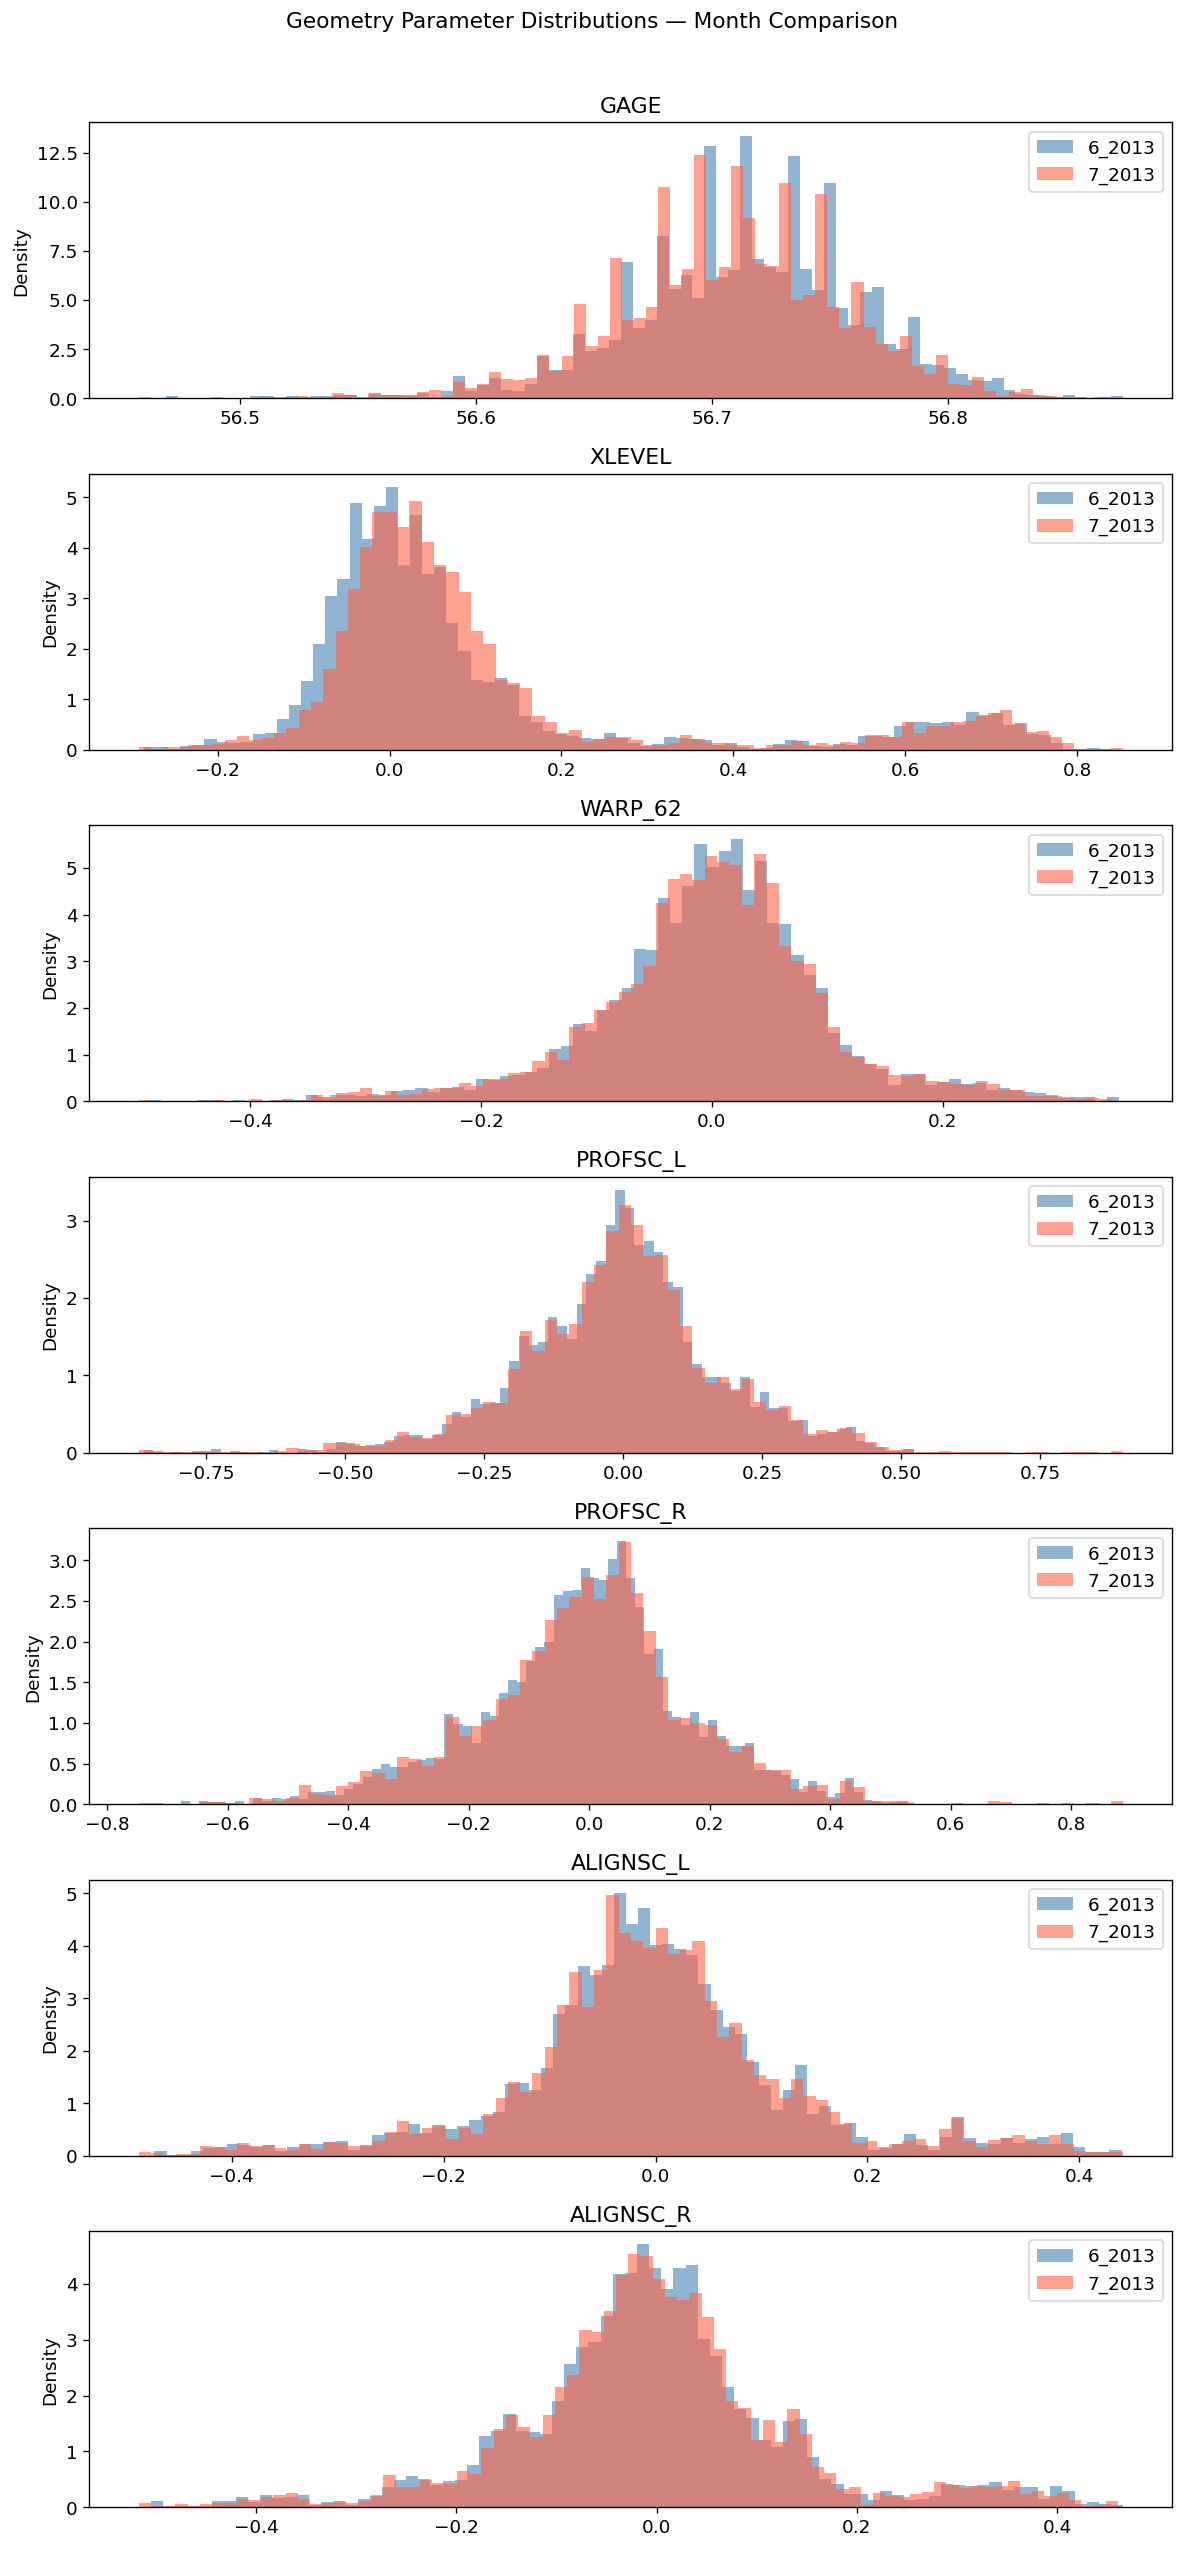

In [6]:
# Distribution of each geometry parameter across both months
fig, axes = plt.subplots(len(GEO_COLS), 1, figsize=(10, 3 * len(GEO_COLS)), sharex=False)

colors = ['steelblue', 'tomato']
for ax, col in zip(axes, GEO_COLS):
    for (m, df), c in zip(frames.items(), colors):
        ax.hist(df[col].dropna(), bins=80, alpha=0.6, color=c, label=m, density=True)
    ax.set_title(col)
    ax.set_ylabel('Density')
    ax.legend()

plt.suptitle('Geometry Parameter Distributions — Month Comparison', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

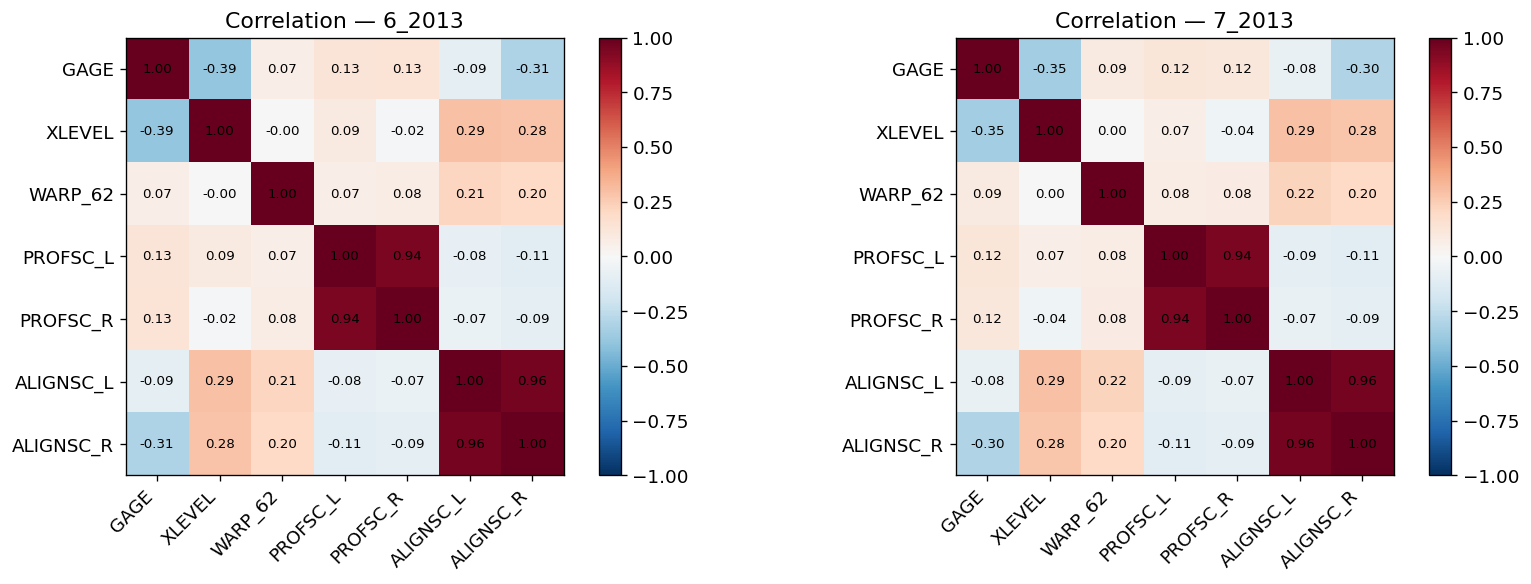

In [7]:
# Correlation heatmap per month
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
import matplotlib.colors as mcolors

for ax, (m, df) in zip(axes, frames.items()):
    corr = df[GEO_COLS].corr()
    im = ax.imshow(corr, cmap='RdBu_r', vmin=-1, vmax=1)
    ax.set_xticks(range(len(GEO_COLS)))
    ax.set_yticks(range(len(GEO_COLS)))
    ax.set_xticklabels(GEO_COLS, rotation=45, ha='right')
    ax.set_yticklabels(GEO_COLS)
    ax.set_title(f'Correlation — {m}')
    for i in range(len(GEO_COLS)):
        for j in range(len(GEO_COLS)):
            ax.text(j, i, f'{corr.iloc[i, j]:.2f}', ha='center', va='center', fontsize=8)
    plt.colorbar(im, ax=ax)

plt.tight_layout()
plt.show()

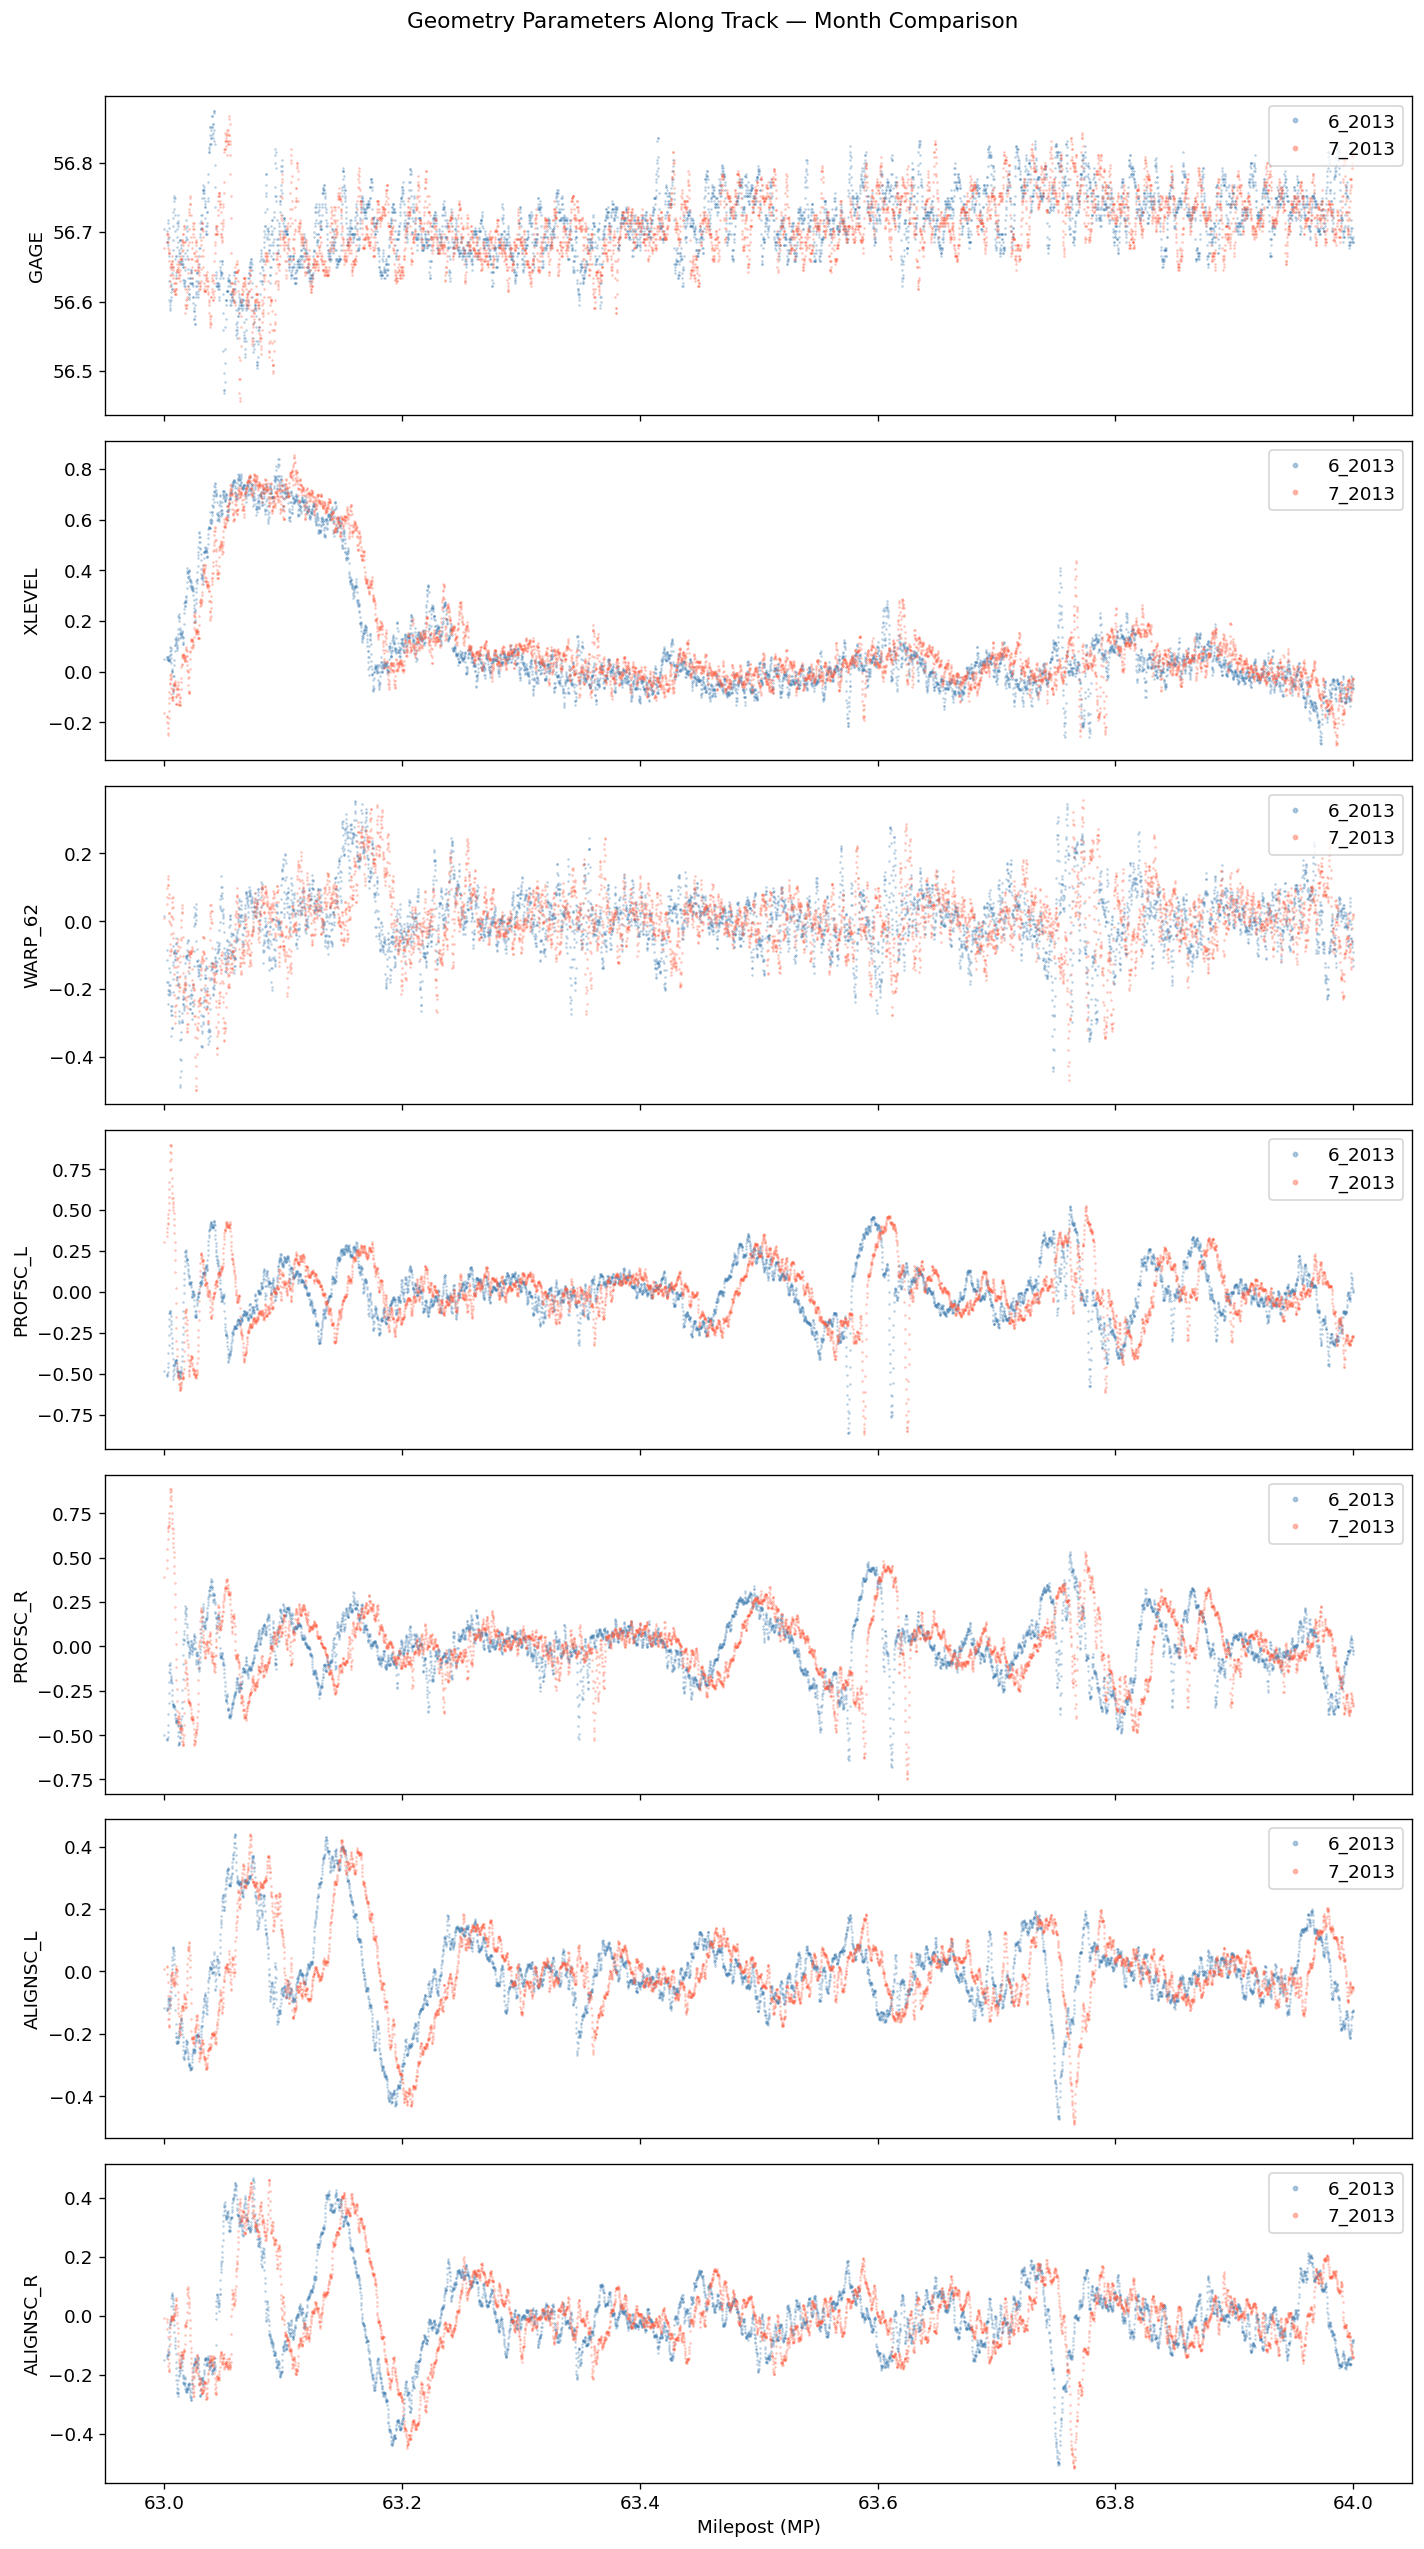

In [8]:
# Spatial profile along track milepost for one parameter
fig, axes = plt.subplots(len(GEO_COLS), 1, figsize=(12, 3 * len(GEO_COLS)), sharex=True)

for ax, col in zip(axes, GEO_COLS):
    for (m, df), c in zip(frames.items(), colors):
        ax.plot(df['MP'].values, df[col].values, '.', markersize=1, alpha=0.4, color=c, label=m)
    ax.set_ylabel(col)
    ax.legend(loc='upper right', markerscale=5)

axes[-1].set_xlabel('Milepost (MP)')
plt.suptitle('Geometry Parameters Along Track — Month Comparison', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

## 3. Feature Engineering

For the prediction task we align measurement points across months by milepost (`MP`), then construct:
- **Current values** at time *t*: the 7 geometry columns
- **First differences** (rate of change): Δ = value(t) − value(t−1)
- **Target**: geometry values at *t+1* (next month)

Scaling to [0, π] is applied for quantum angle encoding (fitted on training data only).

In [9]:
def align_months(df_t0: pd.DataFrame, df_t1: pd.DataFrame, cols: list) -> pd.DataFrame:
    """
    Align two monthly DataFrames on milepost (MP) and construct
    windowed features: current values + first differences + next-month target.
    """
    # Round MP to avoid floating-point mismatch
    df_t0 = df_t0.copy()
    df_t1 = df_t1.copy()
    df_t0['MP_round'] = df_t0['MP'].round(4)
    df_t1['MP_round'] = df_t1['MP'].round(4)

    merged = df_t0[['MP_round'] + cols].merge(
        df_t1[['MP_round'] + cols],
        on='MP_round',
        suffixes=('_t0', '_t1')
    ).dropna()

    # First differences
    for c in cols:
        merged[f'd_{c}'] = merged[f'{c}_t1'] - merged[f'{c}_t0']

    # Feature matrix (t0 values + first differences) and targets (t1 values)
    feature_cols = [f'{c}_t0' for c in cols] + [f'd_{c}' for c in cols]
    target_cols  = [f'{c}_t1' for c in cols]

    X = merged[feature_cols].copy()
    y = merged[target_cols].copy()
    X.columns = [c.replace('_t0', '') for c in feature_cols]
    y.columns = cols

    return X, y, merged['MP_round']


X, y, mp = align_months(frames[MONTHS[0]], frames[MONTHS[1]], GEO_COLS)
print(f'Aligned samples: {len(X)}')
print(f'Feature columns ({len(X.columns)}): {list(X.columns)}')
print(f'Target columns  ({len(y.columns)}): {list(y.columns)}')
X.head()

Aligned samples: 5270
Feature columns (14): ['GAGE', 'XLEVEL', 'WARP_62', 'PROFSC_L', 'PROFSC_R', 'ALIGNSC_L', 'ALIGNSC_R', 'd_GAGE', 'd_XLEVEL', 'd_WARP_62', 'd_PROFSC_L', 'd_PROFSC_R', 'd_ALIGNSC_L', 'd_ALIGNSC_R']
Target columns  (7): ['GAGE', 'XLEVEL', 'WARP_62', 'PROFSC_L', 'PROFSC_R', 'ALIGNSC_L', 'ALIGNSC_R']


,GAGE,XLEVEL,WARP_62,PROFSC_L,PROFSC_R,ALIGNSC_L,ALIGNSC_R,d_GAGE,d_XLEVEL,d_WARP_62,d_PROFSC_L,d_PROFSC_R,d_ALIGNSC_L,d_ALIGNSC_R
0,56.685364,-0.063477,-0.131836,0.000305,-0.041504,-0.125504,-0.082016,0.122070,0.034180,0.145264,-0.278320,-0.295715,0.064468,-0.061417
1,56.685364,-0.068359,-0.114746,0.006409,-0.027466,-0.126266,-0.082397,0.126038,0.041504,0.133057,-0.276794,-0.301514,0.072479,-0.057602
2,56.693298,-0.053711,-0.090332,0.020142,-0.021973,-0.124359,-0.088501,0.121765,0.025635,0.109863,-0.287170,-0.295715,0.074387,-0.051498
3,56.685364,-0.064697,-0.075684,0.030518,-0.001831,-0.129318,-0.085068,0.126038,0.028076,0.080566,-0.301514,-0.312500,0.078201,-0.052261
4,56.689331,-0.041504,-0.065918,0.047302,-0.000916,-0.131607,-0.091553,0.118103,-0.008545,0.046387,-0.323181,-0.299988,0.082779,-0.039291


In [10]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler

# Time-based split (respect temporal order — no shuffle)
split = int(0.8 * len(X))
X_train, X_test = X.iloc[:split], X.iloc[split:]
y_train, y_test = y.iloc[:split], y.iloc[split:]

print(f'Train: {len(X_train)} | Test: {len(X_test)}')

# Scale features to [0, π] for quantum angle encoding
scaler = MinMaxScaler(feature_range=(0, np.pi))
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

# Target scaler (for reporting predictions in original units)
target_scaler = MinMaxScaler()
y_train_scaled = target_scaler.fit_transform(y_train)
y_test_scaled  = target_scaler.transform(y_test)

print('Feature range after scaling (should be [0, π]):')
print(f'  min={X_train_scaled.min():.4f}  max={X_train_scaled.max():.4f}')

Train: 4216 | Test: 1054
Feature range after scaling (should be [0, π]):
  min=0.0000  max=3.1416


## 4. ZZ Feature Map — Quantum Circuit Implementation

We use a pure-numpy statevector simulator (equivalent to Qiskit Aer's statevector backend).

**Circuit structure (depth *d*, *n* qubits — one per geometry parameter):**

For each layer 1 … d:
1. **Hadamard** on all qubits — superposition
2. **Rz(xᵢ)** on qubit *i* — encode feature value as phase rotation
3. **Entangling block** for each pair (i, j): `CNOT(i→j) → Rz(xᵢ·xⱼ) on j → CNOT(i→j)`

**Features extracted from final statevector:**
- Tier 1: ⟨Zᵢ⟩ — 7 features
- Tier 2: ⟨ZᵢZⱼ⟩ — 21 features  &nbsp;&nbsp;→ Tier 1+2 = **28 features**
- Tier 3: ⟨ZᵢZⱼZₖ⟩ — 35 features → Tier 1+2+3 = **63 features**

In [ ]:
from itertools import combinations

# ── Gate definitions ────────────────────────────────────────────────────────

def H_gate():
    return np.array([[1, 1], [1, -1]], dtype=complex) / np.sqrt(2)

def Rz_gate(theta):
    return np.array([[np.exp(-0.5j * theta), 0],
                     [0,  np.exp( 0.5j * theta)]], dtype=complex)

# ── Single-qubit gate applied to an n-qubit statevector ─────────────────────

def apply_1q(sv, gate, qubit, n):
    """Contract gate onto the qubit-th index of the reshaped statevector."""
    sv = sv.reshape([2] * n)
    sv = np.tensordot(gate, sv, axes=([1], [qubit]))   # new axis at position 0
    sv = np.moveaxis(sv, 0, qubit)                     # restore axis order
    return sv.reshape(2**n)

# ── CNOT gate ────────────────────────────────────────────────────────────────

def apply_cnot(sv, ctrl, tgt, n):
    """Flip tgt qubit wherever ctrl qubit is |1⟩."""
    sv = sv.reshape([2] * n)
    idx0 = [slice(None)] * n;  idx0[ctrl] = 1;  idx0[tgt] = 0
    idx1 = [slice(None)] * n;  idx1[ctrl] = 1;  idx1[tgt] = 1
    sv[tuple(idx0)], sv[tuple(idx1)] = sv[tuple(idx1)].copy(), sv[tuple(idx0)].copy()
    return sv.reshape(2**n)

print('Gate primitives defined.')

In [ ]:
def zz_circuit(x, pairs, depth=1):
    """
    Run the ZZ Feature Map circuit for input vector x.
    Returns the final statevector of shape (2^n,).

    x     : 1-D array of length n, values in [0, π]
    pairs : list of (i, j) entanglement pairs
    depth : number of encoding layers
    """
    n  = len(x)
    H  = H_gate()
    sv = np.zeros(2**n, dtype=complex)
    sv[0] = 1.0  # initialise to |00…0⟩

    for _ in range(depth):
        # 1. Hadamard on all qubits
        for i in range(n):
            sv = apply_1q(sv, H, i, n)
        # 2. Single-qubit Rz encoding
        for i in range(n):
            sv = apply_1q(sv, Rz_gate(x[i]), i, n)
        # 3. Pairwise ZZ interactions
        for (i, j) in pairs:
            sv = apply_cnot(sv, i, j, n)
            sv = apply_1q(sv, Rz_gate(x[i] * x[j]), j, n)
            sv = apply_cnot(sv, i, j, n)

    return sv


def extract_expectations(sv, n, tiers=(1, 2)):
    """
    Compute Z-basis expectation values analytically from a statevector.

    Returns a 1-D numpy array of quantum features:
      tiers=(1,2)   →  ⟨Zi⟩ + ⟨ZiZj⟩          = 7 + 21 = 28 features
      tiers=(1,2,3) →  + ⟨ZiZjZk⟩  (35 more)   = 63 features
    """
    probs  = np.abs(sv) ** 2                                      # (2^n,)
    states = np.arange(2**n)
    bits   = ((states[:, None] >> np.arange(n - 1, -1, -1)) & 1) # (2^n, n)
    signs  = 1 - 2 * bits                                         # +1 / -1

    out = []
    if 1 in tiers:
        out.append(probs @ signs)                                  # (n,)
    if 2 in tiers:
        z2 = np.array([probs @ (signs[:, i] * signs[:, j])
                       for i, j in combinations(range(n), 2)])
        out.append(z2)
    if 3 in tiers:
        z3 = np.array([probs @ (signs[:, i] * signs[:, j] * signs[:, k])
                       for i, j, k in combinations(range(n), 3)])
        out.append(z3)
    return np.concatenate(out)


print('Circuit and expectation-value functions defined.')

In [ ]:
# ── Qubit-to-parameter assignment ───────────────────────────────────────────
#
# We have 7 geometry columns (n = 7 qubits):
#   idx  column
#    0   GAGE
#    1   XLEVEL   (crosslevel)
#    2   WARP_62  (warp)
#    3   PROFSC_L (profile left)
#    4   PROFSC_R (profile right)
#    5   ALIGNSC_L (alignment left)
#    6   ALIGNSC_R (alignment right)

N_QUBITS = len(GEO_COLS)   # 7

# ── Entanglement topologies ──────────────────────────────────────────────────

# Linear/nearest-neighbour  — default qubit ordering (Ordering B)
LINEAR_PAIRS = [(i, i + 1) for i in range(N_QUBITS - 1)]

# Full pairwise  — all C(7,2) = 21 pairs
FULL_PAIRS = list(combinations(range(N_QUBITS), 2))

# Physically motivated  — based on known track geometry couplings:
#   • left/right rails of the same parameter are tightly coupled
#   • warp and crosslevel co-vary
#   • gauge and crosslevel are coupled
#   • profile and warp are related (both measure vertical geometry)
PHYSICAL_PAIRS = [
    (3, 4),   # PROFSC_L  ↔ PROFSC_R   (same parameter, L/R)
    (5, 6),   # ALIGNSC_L ↔ ALIGNSC_R  (same parameter, L/R)
    (1, 2),   # XLEVEL    ↔ WARP_62    (crosslevel–warp coupling)
    (0, 1),   # GAGE      ↔ XLEVEL     (gauge–crosslevel coupling)
    (2, 3),   # WARP_62   ↔ PROFSC_L   (warp–profile coupling)
    (2, 4),   # WARP_62   ↔ PROFSC_R
]

# ── Experimental configurations ─────────────────────────────────────────────
# Each entry: (label, pairs, depth, tiers)
QFM_CONFIGS = {
    'Q1': (LINEAR_PAIRS,   1, (1, 2)),
    'Q2': (FULL_PAIRS,     1, (1, 2)),
    'Q3': (FULL_PAIRS,     2, (1, 2)),
    'Q4': (FULL_PAIRS,     1, (1, 2, 3)),
    'Q5': (PHYSICAL_PAIRS, 1, (1, 2)),
}

print('Entanglement topologies:')
print(f'  Linear   : {len(LINEAR_PAIRS)} pairs  → {LINEAR_PAIRS}')
print(f'  Full     : {len(FULL_PAIRS)} pairs')
print(f'  Physical : {len(PHYSICAL_PAIRS)} pairs → {PHYSICAL_PAIRS}')
print()
print('Quantum feature sizes (per config):')
for name, (pairs, depth, tiers) in QFM_CONFIGS.items():
    n1 = N_QUBITS if 1 in tiers else 0
    n2 = len(list(combinations(range(N_QUBITS), 2))) if 2 in tiers else 0
    n3 = len(list(combinations(range(N_QUBITS), 3))) if 3 in tiers else 0
    print(f'  {name}: {n1 + n2 + n3} features  (Tier1={n1}, Tier2={n2}, Tier3={n3})')

In [ ]:
def transform_dataset(X_scaled, pairs, depth=1, tiers=(1, 2)):
    """
    Apply the ZZ feature map to every row of X_scaled (shape: N × n_qubits).
    Returns quantum feature matrix of shape (N, n_features).

    X_scaled must already be in [0, π] — use the first N_QUBITS columns
    (current geometry values) as input to the circuit.
    """
    n = X_scaled.shape[1]
    rows = []
    for x in X_scaled:
        sv  = zz_circuit(x, pairs, depth)
        row = extract_expectations(sv, n, tiers)
        rows.append(row)
    return np.array(rows)

# ── Quick sanity check on a single sample ───────────────────────────────────
x_test = X_train_scaled[0, :N_QUBITS]   # first training point, geometry values only
sv_test = zz_circuit(x_test, LINEAR_PAIRS, depth=1)

print(f'Statevector norm (should be 1.0): {np.sum(np.abs(sv_test)**2):.8f}')
feats = extract_expectations(sv_test, N_QUBITS, tiers=(1, 2))
print(f'Quantum feature vector length (Q1, Tier1+2): {len(feats)}')
print(f'All values in [-1, 1]: {np.all(np.abs(feats) <= 1.0 + 1e-9)}')
print(f'Feature preview: {feats[:7].round(4)}  ...  {feats[-5:].round(4)}')

In [ ]:
import time

# Input to the quantum circuit: current geometry values only (first N_QUBITS cols)
X_tr_q = X_train_scaled[:, :N_QUBITS]
X_te_q = X_test_scaled[:,  :N_QUBITS]

quantum_features = {}   # stores (X_train_qfeat, X_test_qfeat) per config

for name, (pairs, depth, tiers) in QFM_CONFIGS.items():
    t0 = time.time()
    tr = transform_dataset(X_tr_q, pairs, depth, tiers)
    te = transform_dataset(X_te_q, pairs, depth, tiers)
    elapsed = time.time() - t0
    quantum_features[name] = (tr, te)
    print(f'{name}  shape={tr.shape}  time={elapsed:.1f}s')

## 5. Classical Baselines and Model Comparison

We build three classical feature configurations and compare them to the quantum ones using **Ridge Regression** (fast, interpretable linear baseline).

| Config | Features | Size |
|--------|----------|------|
| C1 — Raw | Current geometry + first differences | 14 |
| C2 — Poly | C1 + pairwise products of current values | 35 |
| C3 — Trig | C1 + cos(xᵢ), cos(xᵢ)cos(xⱼ), sin(xᵢ)sin(xⱼ) of current values | 63 |
| Q1–Q5 | ZZ Feature Map expectation values | 28 / 63 |
| H1 — Hybrid | Best Q config + first differences | 28+7=35 |

**C3 is the critical baseline** — if quantum configs beat C1/C2 but not C3, the gain comes from the trigonometric function structure, not quantum entanglement.

In [ ]:
from sklearn.preprocessing import PolynomialFeatures

# Shorthand: current geometry values (scaled to [0,π]), shape (N, 7)
Xtr_cur = X_train_scaled[:, :N_QUBITS]
Xte_cur = X_test_scaled[:,  :N_QUBITS]

# Shorthand: first differences (already scaled), shape (N, 7)
Xtr_dif = X_train_scaled[:, N_QUBITS:]
Xte_dif = X_test_scaled[:,  N_QUBITS:]

# ── C1: raw (current values + first differences) ────────────────────────────
C1_tr = X_train_scaled        # (N, 14)
C1_te = X_test_scaled

# ── C2: C1 + pairwise products of current values ────────────────────────────
def poly2_interactions(A):
    """Return pairwise products xᵢ·xⱼ (no squares, no bias)."""
    cols = [A[:, i] * A[:, j] for i, j in combinations(range(A.shape[1]), 2)]
    return np.column_stack(cols)

C2_tr = np.hstack([C1_tr, poly2_interactions(Xtr_cur)])
C2_te = np.hstack([C1_te, poly2_interactions(Xte_cur)])

# ── C3: C1 + trig features of current values ────────────────────────────────
#   cos(xᵢ)              — 7 features
#   cos(xᵢ)·cos(xⱼ)     — 21 features
#   sin(xᵢ)·sin(xⱼ)     — 21 features
def trig_features(A):
    c, s = np.cos(A), np.sin(A)
    cos_i     = c                                                           # (N, 7)
    cos_cross = np.column_stack([c[:, i] * c[:, j]
                                 for i, j in combinations(range(A.shape[1]), 2)])
    sin_cross = np.column_stack([s[:, i] * s[:, j]
                                 for i, j in combinations(range(A.shape[1]), 2)])
    return np.hstack([cos_i, cos_cross, sin_cross])                        # (N, 49)

C3_tr = np.hstack([C1_tr, trig_features(Xtr_cur)])
C3_te = np.hstack([C1_te, trig_features(Xte_cur)])

print('Classical feature set sizes:')
print(f'  C1 : {C1_tr.shape[1]} features')
print(f'  C2 : {C2_tr.shape[1]} features')
print(f'  C3 : {C3_tr.shape[1]} features')

In [ ]:
from sklearn.linear_model import RidgeCV
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

def evaluate(X_tr, y_tr, X_te, y_te, label):
    """
    Fit Ridge regression (with cross-validated alpha) on each target column.
    Returns a dict with per-target and mean metrics.
    """
    alphas = np.logspace(-3, 3, 20)
    rmse_list, mae_list, r2_list = [], [], []

    for col in y_tr.columns:
        model = RidgeCV(alphas=alphas, cv=5)
        model.fit(X_tr, y_tr[col])
        pred  = model.predict(X_te)
        rmse_list.append(np.sqrt(mean_squared_error(y_te[col], pred)))
        mae_list.append(mean_absolute_error(y_te[col], pred))
        r2_list.append(r2_score(y_te[col], pred))

    return {
        'config' : label,
        'n_feats': X_tr.shape[1],
        'RMSE'   : np.mean(rmse_list),
        'MAE'    : np.mean(mae_list),
        'R²'     : np.mean(r2_list),
    }

# ── Assemble all feature matrices ───────────────────────────────────────────
feature_sets = {
    'C1': (C1_tr, C1_te),
    'C2': (C2_tr, C2_te),
    'C3': (C3_tr, C3_te),
}
# Add quantum configs
for name, (qtr, qte) in quantum_features.items():
    feature_sets[name] = (qtr, qte)
# H1: best individual Q + classical differences (use Q2 as default best)
feature_sets['H1'] = (
    np.hstack([quantum_features['Q2'][0], Xtr_dif]),
    np.hstack([quantum_features['Q2'][1], Xte_dif]),
)

# ── Train and evaluate all configurations ───────────────────────────────────
results = []
for label, (Xtr, Xte) in feature_sets.items():
    res = evaluate(Xtr, y_train, Xte, y_test, label)
    results.append(res)
    print(f"{label:4s}  n_feat={res['n_feats']:3d}  "
          f"RMSE={res['RMSE']:.5f}  MAE={res['MAE']:.5f}  R²={res['R²']:.4f}")

In [ ]:
# ── Results table ───────────────────────────────────────────────────────────
df_res = pd.DataFrame(results).sort_values('RMSE').reset_index(drop=True)
df_res['RMSE'] = df_res['RMSE'].round(5)
df_res['MAE']  = df_res['MAE'].round(5)
df_res['R²']   = df_res['R²'].round(4)

# Highlight the best row
best_idx = df_res['RMSE'].idxmin()
display(df_res.style
        .highlight_min(subset=['RMSE', 'MAE'], color='#c6efce')
        .highlight_max(subset=['R²'],           color='#c6efce')
        .set_caption('Ridge Regression — mean across all 7 geometry parameters (test set)')
        .format({'RMSE': '{:.5f}', 'MAE': '{:.5f}', 'R²': '{:.4f}'}))

# ── Bar chart ────────────────────────────────────────────────────────────────
labels = df_res['config'].tolist()
rmse   = df_res['RMSE'].tolist()

colors_bar = ['#4472C4' if l.startswith('C') else
              '#ED7D31' if l.startswith('Q') else '#70AD47'
              for l in labels]

fig, ax = plt.subplots(figsize=(10, 4))
bars = ax.bar(labels, rmse, color=colors_bar, edgecolor='white', linewidth=0.8)
ax.set_ylabel('Mean Test RMSE (lower is better)')
ax.set_title('Classical vs. Quantum Feature Configurations — Ridge Regression')
ax.axhline(df_res.loc[df_res['config'] == 'C1', 'RMSE'].values[0],
           color='grey', linestyle='--', linewidth=1, label='C1 baseline')
ax.legend()
for bar, val in zip(bars, rmse):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.0001,
            f'{val:.4f}', ha='center', va='bottom', fontsize=9)
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor='#4472C4', label='Classical'),
                   Patch(facecolor='#ED7D31', label='Quantum'),
                   Patch(facecolor='#70AD47', label='Hybrid')]
ax.legend(handles=legend_elements, loc='upper right')
plt.tight_layout()
plt.show()

## 6. Next Steps

- [ ] **XGBoost / CatBoost** — repeat Section 5 with gradient boosting models
- [ ] **Per-parameter breakdown** — report RMSE per geometry column (not just mean)
- [ ] **Wilcoxon significance test** — determine if quantum vs. classical differences are statistically significant across track segments
- [ ] **Qubit ordering A** — re-run Q1/Q5 with physically motivated qubit ordering (Profile–Warp–Crosslevel–Gauge–Alignment) and compare
- [ ] **SHAP analysis** — identify which quantum features drive predictions for the best config
- [ ] **Circuit ablation** — remove entangling gates one pair at a time; measure RMSE change
- [ ] **Fourier spectrum** — compare circuit frequency spectrum to dominant frequencies in geometry time series
- [ ] **Scale up** — extend from 2 months (prototype) to all 28 months with proper time-series cross-validation